In [ ]:
import json
import os
import math
import librosa

dataset_path = "/content/drive/MyDrive/bronze and SS audio_corrected/Bronze"

JSON_PATH='/content/drive/MyDrive/bronze and SS audio_corrected/Bronze/bronze_feature_mixed'
SAMPLE_RATE = 8000

SAMPLES_PER_TRACK=47495 #total number of samples for each data

def save_mfcc(dataset_path, json_path, num_mfcc=13, n_fft=2048, hop_length=512, num_segments=5):
      data = {
              "mapping": [], #array 2 section(good,bad)
              "labels": [], #target
              "mfcc": [] #vector of array, each vector correspond to label 0 or 1 ,training input
          }

      samples_per_segment = int(SAMPLES_PER_TRACK / num_segments)
  
      num_mfcc_vectors_per_segment = math.ceil(samples_per_segment / hop_length)    
 
      for i, (dirpath, dirnames, filenames) in enumerate(os.walk(dataset_path)): #current folder dirpath,subfolder dirnames,name file in dirpath
              
              # ensure we're processing a genre sub-folder level
              
              if dirpath is not dataset_path:

                  semantic_label = dirpath.split("/")[-1] #audio_bronze/good_bead==[get good  bead[-1] means last]
                  data["mapping"].append(semantic_label)
                  print("\nProcessing: {}".format(semantic_label))
                  for f in filenames:

                      # load audio file
                      file_path = os.path.join(dirpath, f)
                      signal1, sample_rate = librosa.load(file_path, sr=SAMPLE_RATE)
                      
                      Factor=int(len(signal1)/SAMPLES_PER_TRACK)
                      s=0 #starting index
                      e= SAMPLES_PER_TRACK*Factor #ending index
                      signal=signal1[s:e:Factor]
                     

                      # process all segments of audio file
                      for d in range(num_segments):

                          # calculate start and finish sample for current segment 
                          start = samples_per_segment * d
                          finish = start + samples_per_segment
                        
                          # extract mfcc
                          mfcc = librosa.feature.mfcc(signal[start:finish], sample_rate, n_mfcc=13,n_fft=2048, hop_length=512)
                          mfcc = mfcc.T #transpose of mfcc
                          # print(mfcc)#class tuple

                          # store only mfcc feature with expected number of vectors
                          if len(mfcc) == num_mfcc_vectors_per_segment:
                              data["mfcc"].append(mfcc.tolist())
                              data["labels"].append(i-1)

        
                              print("{}, segment:{}".format(file_path, d+1))
       # save MFCCs to json file
      with open(json_path, "w") as fp:
        json.dump(data, fp, indent=4)                       

# if __name__ == "__main__":
save_mfcc(dataset_path, JSON_PATH, num_segments=10)




4749
10

Processing: B_good_bead
/content/drive/MyDrive/bronze and SS audio_corrected/Bronze/B_good_bead/bead_3_1.wav, segment:1
/content/drive/MyDrive/bronze and SS audio_corrected/Bronze/B_good_bead/bead_3_1.wav, segment:2
/content/drive/MyDrive/bronze and SS audio_corrected/Bronze/B_good_bead/bead_3_1.wav, segment:3
/content/drive/MyDrive/bronze and SS audio_corrected/Bronze/B_good_bead/bead_3_1.wav, segment:4
/content/drive/MyDrive/bronze and SS audio_corrected/Bronze/B_good_bead/bead_3_1.wav, segment:5
/content/drive/MyDrive/bronze and SS audio_corrected/Bronze/B_good_bead/bead_3_1.wav, segment:6
/content/drive/MyDrive/bronze and SS audio_corrected/Bronze/B_good_bead/bead_3_1.wav, segment:7
/content/drive/MyDrive/bronze and SS audio_corrected/Bronze/B_good_bead/bead_3_1.wav, segment:8
/content/drive/MyDrive/bronze and SS audio_corrected/Bronze/B_good_bead/bead_3_1.wav, segment:9
/content/drive/MyDrive/bronze and SS audio_corrected/Bronze/B_good_bead/bead_3_1.wav, segment:10
/conte

Data succesfully loaded!
(520, 10, 13)
Data succesfully loaded!
(260, 10, 13)
(Bad):  180
(Good):  600
(195,)
(468, 10, 13)
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 130)               0         
_________________________________________________________________
dense (Dense)                (None, 512)               67072     
_________________________________________________________________
dense_1 (Dense)              (None, 256)               131328    
_________________________________________________________________
dense_2 (Dense)              (None, 64)                16448     
_________________________________________________________________
dense_3 (Dense)              (None, 2)                 130       
Total params: 214,978
Trainable params: 214,978
Non-trainable params: 0
__________________________________________________________

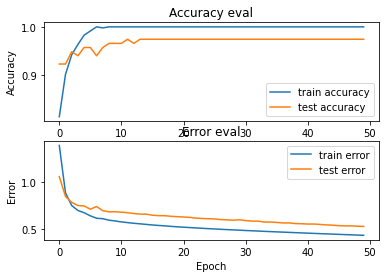

In [ ]:
import json
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow.keras as keras
import matplotlib.pyplot as plt
import time


DATA_PATH1 = '/content/drive/MyDrive/bronze and SS audio_corrected/stainless_steel/data_feature_SS_final.json' #520 for stainless steel
DATA_PATH2 = "/content/drive/MyDrive/bronze and SS audio_corrected/Bronze/bronze_feature_mixed" #260 for bronze
     


def load_data(data_path):
    """Loads training dataset from json file.
        :param data_path (str): Path to json file containing data
        :return X (ndarray): Inputs
        :return y (ndarray): Targets
    """

    with open(data_path, "r") as fp:
        data = json.load(fp)

    # convert lists to numpy arrays
    X = np.array(data["mfcc"])
    y = np.array(data["labels"])

    print("Data succesfully loaded!")

    return  X, y

def plot_history(History):
    """Plots accuracy/loss for training/validation set as a function of the epochs
        :param history: Training history of model
        :return:
    """

    fig, axs = plt.subplots(2)
    history,test_loss,test_acc,t3,t5=History()
    # create accuracy sublpot
    axs[0].plot(history.history["accuracy"], label="train accuracy")
    axs[0].plot(history.history["val_accuracy"], label="test accuracy")
    axs[0].set_ylabel("Accuracy")
    axs[0].legend(loc="lower right")
    axs[0].set_title("Accuracy eval")

    # create error sublpot
    axs[1].plot(history.history["loss"], label="train error")
    axs[1].plot(history.history["val_loss"], label="test error")
    axs[1].set_ylabel("Error")
    axs[1].set_xlabel("Epoch")
    axs[1].legend(loc="upper right")
    axs[1].set_title("Error eval")

    plt.show()   

  

def prepare_datasets(test_size, validation_size):
    """Loads data and splits it into train, validation and test sets.
    :param test_size (float): Value in [0, 1] indicating percentage of data set to allocate to test split
    :param validation_size (float): Value in [0, 1] indicating percentage of train set to allocate to validation split
    :return X_train (ndarray): Input training set
    :return X_validation (ndarray): Input validation set
    :return X_test (ndarray): Input test set
    :return y_train (ndarray): Target training set
    :return y_validation (ndarray): Target validation set
    :return y_test (ndarray): Target test set
    """

    X1, y1 = load_data(DATA_PATH1)
    # y1 = 1- y1
    print(X1.shape)
    X2,y2=load_data(DATA_PATH2)
    print(X2.shape)
    X=np.concatenate((X1, X2))
    y= np.concatenate((y1, y2))
    print('(Bad): ',sum(y))
    print('(Good): ', len(y)- sum(y))
    

    # create train, validation and test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
    
    print(y_test.shape)
    X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size=validation_size)
    print(X_train.shape)
    return X_train, X_validation, X_test, y_train, y_validation, y_test     


    
def History():
    # create train/test split
    X_train, X_validation, X_test, y_train, y_validation, y_test = prepare_datasets(0.25, 0.20)

    # build network topology
    model = keras.Sequential([

        # input layer
        keras.layers.Flatten(input_shape=(X_train.shape[1], X_train.shape[2])),
        
        # 1st dense layer
        keras.layers.Dense(512, activation='relu',kernel_regularizer=keras.regularizers.l2(0.001)),
     
        # 2nd dense layer
        keras.layers.Dense(256, activation='relu',kernel_regularizer=keras.regularizers.l2(0.001)),
       
        # 3rd dense layer
        keras.layers.Dense(64, activation='relu',kernel_regularizer=keras.regularizers.l2(0.001)),
        
        # output layer
        keras.layers.Dense(2, activation='softmax')
    ])

    # compile model
    optimiser = keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(optimizer=optimiser,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    model.summary()

    # train model

    history = model.fit(X_train, y_train, validation_data=(X_validation, y_validation), batch_size=16, epochs=50)


   # evaluate model on test set
    t4=time.time() 
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
    print('\nTest accuracy:', test_acc)
 
    return history,test_loss,test_acc

  
# if __name__ == "__main__":  
plot_history(History)  




Data succesfully loaded!
(520, 10, 13)
Data succesfully loaded!
(260, 10, 13)
(Bad):  180
(Good):  600
(195,)
(468, 10, 13)
Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_2 (Flatten)          (None, 130)               0         
_________________________________________________________________
dense_8 (Dense)              (None, 512)               67072     
_________________________________________________________________
dense_9 (Dense)              (None, 256)               131328    
_________________________________________________________________
dense_10 (Dense)             (None, 64)                16448     
_________________________________________________________________
dense_11 (Dense)             (None, 2)                 130       
Total params: 214,978
Trainable params: 214,978
Non-trainable params: 0
________________________________________________________

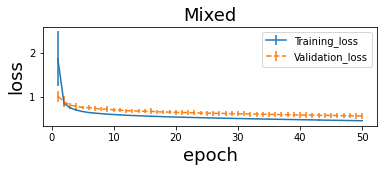

In [ ]:
# def marix_generation():
import numpy 
import matplotlib.pyplot as plt
T_loss=[]
T_Accuracy=[]
V_loss=[]
V_Accuracy=[]
test=[]
train_time=[]
test_time=[]
for i in range(25):
  
  h,test_loss,test_acc,tr_time,te_time=History()
  test.append(test_acc)
  train_time.append(tr_time)
  test_time.append(te_time)
  T_loss.append(h.history["loss"])
  T_Accuracy.append(h.history["accuracy"])
  V_loss.append(h.history["val_loss"])
  V_Accuracy.append(h.history["val_accuracy"])

T_loss_final = numpy.stack(T_loss, axis=0)    
T_accuracy_final= numpy.stack(T_Accuracy, axis=0)
V_loss_final = numpy.stack(V_loss, axis=0) 
V_accuracy_final= numpy.stack(V_Accuracy, axis=0)

mean_T_loss=T_loss_final.mean(0)
mean_T_accuracy=T_accuracy_final.mean(0)
mean_V_loss=V_loss_final.mean(0)
mean_V_accuracy=V_accuracy_final.mean(0)

std_T_loss=T_loss_final.std(0)
std_T_accuracy=T_accuracy_final.std(0)
std_V_loss=V_loss_final.std(0)
std_V_accuracy=V_accuracy_final.std(0)

plt.subplot(211)
plt.title('Mixed',fontsize=18)
plt.errorbar(range(1,51),mean_T_loss, yerr=std_T_loss, label='Training_loss')
plt.errorbar(range(1,51),mean_V_loss, yerr=std_V_loss,ls='--', label='Validation_loss')
plt.ylabel("loss", fontsize=18)
plt.xlabel("epoch", fontsize=18)
plt.legend(loc='upper right')

# plt.subplot(212)
# # plt.title('accuracy')
# plt.errorbar(range(1,51),mean_T_accuracy, yerr=std_T_accuracy, label='Training_acc.')
# plt.errorbar(range(1,51),mean_V_accuracy, yerr=std_V_accuracy,ls='--', label='Validation_acc.')
# plt.ylabel("accuracy")
# plt.xlabel("epoch")
# plt.legend(loc='lower right')
plt.savefig("NN_together.PDF")
plt.show()


In [ ]:
print(mean_V_accuracy[-1])
print(std_V_accuracy[-1])
print(mean_T_accuracy[-1])
print(std_T_accuracy[-1])

print(numpy.mean(test_time))
print(numpy.mean(train_time))
print(numpy.mean(test))
print(numpy.std(test))

0.9647863268852234
0.015539579487257392
1.0
0.0
0.08437409400939941
13.349210014343262
0.9585641050338745
0.013208089495407443
